# Effect of kinematic conditions on Mass, radial velocity and tangential velocity depending on cosmology

In [1]:
import pandas as pd

suffix = 'final_rev'

df_results = pd.read_pickle('../results/' + suffix + '/cosmo_results.pkl')
df_results = df_results.sort_index()

df_analysis_significant = pd.read_pickle('../results/' + suffix + '/cosmo_analysis.pkl')
df_analysis_all = pd.read_pickle('../results/' + suffix + '/cosmo_analysis_all.pkl')

df_dists = pd.read_pickle('../results/' + suffix + '/dists.pkl')

In [2]:
df_results['pvalue_corrected'] = df_results['pvalue'] * 93
df_results['significant_corrected'] = df_results['pvalue_corrected'] < 0.05

In [3]:
df_results.loc['c171']

Mode        Median          Mean           Std  \
variable filter                                                           
mass_LG  Pract   5.610950e+12  6.386246e+12  6.405007e+12  1.239283e+12   
         Real    6.501878e+12  6.354021e+12  6.375632e+12  1.250246e+12   
         Trad    6.892369e+12  6.380560e+12  6.409996e+12  1.252504e+12   
vrel_rad Pract  -3.950256e+02 -7.459642e+01 -8.261898e+01  5.562055e+01   
         Real   -3.823266e+02 -7.141411e+01 -7.926243e+01  5.424564e+01   
         Trad   -6.804353e+02 -7.688136e+01 -8.486782e+01  5.713793e+01   
vrel_tan Pract   1.338763e+01  1.262223e+02  1.400316e+02  6.487057e+01   
         Real    1.338763e+01  1.251236e+02  1.406297e+02  6.779863e+01   
         Trad    8.246023e+00  1.267237e+02  1.410115e+02  6.508998e+01   

                          Min           Max    Size    M diff  statistic  \
variable filter                                                            
mass_LG  Pract   2.915419e+12  9.860865e+12    5612 -0.077836   0.008395   
         Real    3.002616e+12  9.864656e+12    4552 -0.536112   0.016602   
         Trad    2.593169e+12  9.978392e+12  206014       NaN        NaN   
vrel_rad Pract  -3.950256e+02 -4.211712e-02    5612 -2.649816   0.018781   
         Real   -3.823266e+02 -6.213087e-02    4552 -6.604844   0.046105   
         Trad   -6.804353e+02 -1.250135e-03  206014       NaN        NaN   
vrel_tan Pract   1.338763e+01  6.412955e+02    5612 -0.694903   0.013405   
         Real    1.338763e+01  6.738510e+02    4552 -0.270762   0.014519   
         Trad    8.246023e+00  8.640341e+02  206014       NaN        NaN   

                       pvalue  significant  pvalue_corrected  \
variable filter                                                
mass_LG  Pract   8.328563e-01        False         77.455640   
         Real    1.696581e-01        False         15.778201   
         Trad             NaN        False               NaN   
vrel_rad Pract   4.186418e-02         True          3.893368   
         Real    1.149863e-08         True          0.000001   
         Trad             NaN        False               NaN   
vrel_tan Pract   2.775424e-01        False         25.811448   
         Real    3.018799e-01        False         28.074830   
         Trad             NaN        False               NaN   

                 significant_corrected  
variable filter                         
mass_LG  Pract                   False  
         Real                    False  
         Trad                    False  
vrel_rad Pract                   False  
         Real                     True  
         Trad                    False  
vrel_tan Pract                   False  
         Real                    False  
         Trad                    False

In [4]:
sig_real = df_results.xs(('vrel_rad', 'Real'), level=('variable', 'filter'))['significant_corrected']
sig_pract = df_results.xs(('vrel_rad', 'Pract'), level=('variable', 'filter'))['significant_corrected']

# Join on the matching cosmo index
both = sig_real & sig_pract

# Filter df_results to only rows whose cosmo match the "both == True"
df_results.loc[both.index[both]]

Mode        Median          Mean           Std  \
cosmo variable filter                                                           
c152  mass_LG  Pract   7.139795e+12  6.520714e+12  6.535462e+12  1.217487e+12   
               Real    6.365944e+12  6.471839e+12  6.499306e+12  1.247270e+12   
               Trad    6.728432e+12  6.512568e+12  6.535579e+12  1.220468e+12   
      vrel_rad Pract  -4.707592e+02 -7.653315e+01 -8.419147e+01  5.533918e+01   
               Real   -3.544314e+02 -7.546094e+01 -8.219681e+01  5.412981e+01   
               Trad   -5.510946e+02 -7.982440e+01 -8.696807e+01  5.666750e+01   
      vrel_tan Pract   5.903917e+00  1.278192e+02  1.409618e+02  6.513953e+01   
               Real    2.112852e+01  1.289701e+02  1.419139e+02  6.563559e+01   
               Trad    5.903917e+00  1.252313e+02  1.389206e+02  6.234414e+01   

                                Min           Max    Size    M diff  \
cosmo variable filter                                                 
c152  mass_LG  Pract   2.936561e+12  9.958242e+12    5591 -0.001788   
               Real    2.936561e+12  9.876784e+12    3269 -0.555015   
               Trad    2.814374e+12  9.990826e+12  252230       NaN   
      vrel_rad Pract  -4.707592e+02 -2.326179e-02    5591 -3.192674   
               Real   -3.544314e+02 -3.402335e-02    3269 -5.486229   
               Trad   -5.510946e+02 -7.488751e-04  252230       NaN   
      vrel_tan Pract   5.903917e+00  6.003864e+02    5591  1.469332   
               Real    2.112852e+01  6.003864e+02    3269  2.154701   
               Trad    5.903917e+00  8.729300e+02  252230       NaN   

                       statistic    pvalue  significant  pvalue_corrected  \
cosmo variable filter                                                       
c152  mass_LG  Pract    0.011206  0.494566        False         45.994662   
               Real     0.022363  0.078109        False          7.264166   
               Trad          NaN       NaN        False               NaN   
      vrel_rad Pract    0.028328  0.000302         True          0.028058   
               Real     0.041942  0.000023         True          0.002113   
               Trad          NaN       NaN        False               NaN   
      vrel_tan Pract    0.020623  0.018805         True          1.748911   
               Real     0.025346  0.031111         True          2.893280   
               Trad          NaN       NaN        False               NaN   

                       significant_corrected  
cosmo variable filter                         
c152  mass_LG  Pract                   False  
               Real                    False  
               Trad                    False  
      vrel_rad Pract                    True  
               Real                     True  
               Trad                    False  
      vrel_tan Pract                   False  
               Real                    False  
               Trad                    False

In [5]:
vr_both = df_results.loc[
    pd.IndexSlice[both.index[both], 'vrel_rad', ['Real', 'Pract']]
]
len(vr_both.index.unique('cosmo'))

1

## Significant differences

In [6]:
#df_results_significant = df_results[df_results['significant'] == True]
df_results_significant = df_results[df_results['pvalue'] < 0.05]

### Mass

In [7]:
df_results_significant.xs('mass_LG', level='variable').sort_values('M diff')

,,Mode,Median,Mean,Std,Min,Max,Size,M diff,statistic,pvalue,significant,pvalue_corrected,significant_corrected
cosmo,filter,,,,,,,,,,,,,
c101,Real,6.974547e+12,6.360114e+12,6.374860e+12,1.247940e+12,1.963992e+12,9.907734e+12,4053,-1.001619,0.022315,0.037484,True,3.485999,False
c003,Real,5.297929e+12,6.036799e+12,6.084440e+12,1.316554e+12,2.716721e+12,9.960235e+12,4545,-0.932836,0.024202,0.010600,True,0.985780,False
c167,Real,5.788715e+12,6.259807e+12,6.318256e+12,1.267252e+12,3.058526e+12,9.814407e+12,3525,-0.890170,0.029961,0.003846,True,0.357636,False
c178,Real,5.580648e+12,6.083477e+12,6.150334e+12,1.291814e+12,2.811275e+12,9.877556e+12,5578,-0.867855,0.026311,0.001006,True,0.093598,False
c135,Real,6.310719e+12,6.146546e+12,6.198380e+12,1.314677e+12,2.958713e+12,9.904473e+12,4256,-0.859594,0.028152,0.002572,True,0.239179,False
c108,Real,5.548046e+12,6.154801e+12,6.215600e+12,1.284173e+12,2.133559e+12,9.969827e+12,5416,-0.798887,0.023915,0.004535,True,0.421739,False
c126,Real,5.801964e+12,6.375666e+12,6.398395e+12,1.258341e+12,3.034485e+12,9.846742e+12,3859,-0.791337,0.023103,0.034442,True,3.203108,False
c155,Real,5.305513e+12,6.182184e+12,6.200466e+12,1.273855e+12,2.518361e+12,9.846007e+12,5277,-0.765140,0.020809,0.022027,True,2.048557,False
c124,Real,6.175444e+12,6.329382e+12,6.386052e+12,1.244699e+12,3.125312e+12,9.844910e+12,4021,-0.579611,0.022227,0.039924,True,3.712918,False


### Radial velocity

In [8]:
df_results_significant.xs('vrel_rad', level='variable').sort_values('M diff')

,,Mode,Median,Mean,Std,Min,Max,Size,M diff,statistic,pvalue,significant,pvalue_corrected,significant_corrected
cosmo,filter,,,,,,,,,,,,,
c004,Real,-330.472062,-72.611771,-81.266741,55.623301,-330.472062,-0.224705,2911,-6.825145,0.051581,4.515747e-07,True,0.000042,True
c171,Real,-382.326561,-71.414109,-79.262431,54.245637,-382.326561,-0.062131,4552,-6.604844,0.046105,1.149863e-08,True,0.000001,True
c139,Real,-314.255837,-74.471046,-82.584782,56.136456,-314.255837,-0.036232,2432,-6.352195,0.043814,1.965686e-04,True,0.018281,True
c160,Real,-363.660015,-73.753380,-81.336412,54.615525,-363.660015,-0.147932,2530,-6.213233,0.042546,2.409641e-04,True,0.022410,True
c164,Real,-369.735376,-69.981857,-78.429490,54.280086,-369.735376,-0.076420,4319,-6.194411,0.040857,1.411854e-06,True,0.000131,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c134,Pract,-479.977359,-72.014272,-80.395543,55.052541,-479.977359,-0.037295,8810,-2.241624,0.016242,2.140243e-02,True,1.990426,False
c148,Pract,-423.932964,-75.931738,-83.308549,55.539013,-423.932964,-0.004943,6486,-2.096041,0.020620,9.063324e-03,True,0.842889,False
c017,Pract,-372.972309,-76.079431,-83.946354,55.288612,-372.972309,-0.014749,5353,-2.044403,0.019580,3.609420e-02,True,3.356761,False


### Tangential velocity

In [9]:
df_results_significant.xs('vrel_tan', level='variable').sort_values('M diff', ascending=False)

,,Mode,Median,Mean,Std,Min,Max,Size,M diff,statistic,pvalue,significant,pvalue_corrected,significant_corrected
cosmo,filter,,,,,,,,,,,,,
c004,Real,21.364822,131.234676,145.163512,70.301045,21.364822,825.693695,2911,2.989649,0.033850,0.002731,True,0.253960,False
c130,Real,22.720119,131.627452,145.380940,68.456442,22.720119,676.700800,2322,2.972298,0.032828,0.013958,True,1.298054,False
c170,Real,24.951549,129.663834,145.010290,68.980854,24.951549,612.308579,1870,2.485794,0.032356,0.041350,True,3.845571,False
c152,Real,21.128523,128.970064,141.913880,65.635587,21.128523,600.386365,3269,2.154701,0.025346,0.031111,True,2.893280,False
c135,Real,15.741077,125.996115,141.196543,67.547743,15.741077,566.893881,4256,1.845866,0.022709,0.026233,True,2.439674,False
c177,Real,9.514962,125.900957,141.168793,67.721242,9.514962,581.111522,6371,1.755079,0.020080,0.012655,True,1.176910,False
c140,Real,16.990035,126.287229,141.589393,68.460050,16.990035,632.869888,3956,1.724577,0.024540,0.018090,True,1.682402,False
c002,Real,13.294013,126.476688,140.350729,66.953410,13.294013,630.395357,6777,1.716253,0.017385,0.035782,True,3.327761,False
c111,Real,15.748807,130.032945,143.009805,67.405283,15.748807,653.088085,4131,1.634009,0.021497,0.046506,True,4.325054,False


## All cosmologies

In [10]:
df_analysis_significant

mean                                            \
                         Mode        Median          Mean           Std   
variable filter                                                           
mass_LG  Real    5.864836e+12  6.214309e+12  6.258531e+12  1.277701e+12   
         Trad    6.410593e+12  6.407040e+12  6.435206e+12  1.247091e+12   
vrel_rad Pract  -3.944837e+02 -7.538342e+01 -8.312399e+01  5.552243e+01   
         Real   -4.084129e+02 -7.315550e+01 -8.128554e+01  5.533714e+01   
         Trad   -6.436909e+02 -7.771047e+01 -8.539863e+01  5.673842e+01   
vrel_tan Pract   1.096146e+01  1.236779e+02  1.377617e+02  6.423566e+01   
         Real    1.766771e+01  1.282381e+02  1.425005e+02  6.799153e+01   
         Trad    7.826901e+00  1.260340e+02  1.401167e+02  6.385234e+01   

                                                                      \
                          Min           Max           Size    M diff   
variable filter                                                        
mass_LG  Real    2.702327e+12  9.885766e+12    4503.333333 -0.831894   
         Trad    2.503681e+12  9.984605e+12  216768.881720       NaN   
vrel_rad Pract  -3.944837e+02 -2.796491e-02    5714.486486 -2.837994   
         Real   -4.084129e+02 -4.542260e-02    4180.093023 -4.643570   
         Trad   -6.436909e+02 -7.083665e-04  216768.881720       NaN   
vrel_tan Pract   1.096146e+01  6.674017e+02    6632.166667 -0.749862   
         Real    1.766771e+01  6.256630e+02    3869.266667  1.632799   
         Trad    7.826901e+00  8.684023e+02  216768.881720       NaN   

                                                num_cosmo  
                statistic    pvalue significant    counts  
variable filter                                            
mass_LG  Real    0.024555  0.017382         1.0         9  
         Trad         NaN       NaN         0.0        93  
vrel_rad Pract   0.021971  0.018677         1.0        37  
         Real    0.033905  0.002653         1.0        86  
         Trad         NaN       NaN         0.0        93  
vrel_tan Pract   0.019469  0.022881         1.0        12  
         Real    0.024903  0.030513         1.0        15  
         Trad         NaN       NaN         0.0        93

In [11]:
df_analysis_all

mean_all                                            \
                         Mode        Median          Mean           Std   
variable filter                                                           
mass_LG  Pract   6.209978e+12  6.403039e+12  6.430839e+12  1.249446e+12   
         Real    6.217345e+12  6.384546e+12  6.415079e+12  1.255116e+12   
         Trad    6.410593e+12  6.407040e+12  6.435206e+12  1.247091e+12   
vrel_rad Pract  -3.989325e+02 -7.588839e+01 -8.356316e+01  5.560568e+01   
         Real   -4.071004e+02 -7.342286e+01 -8.154312e+01  5.541200e+01   
         Trad   -6.436909e+02 -7.771047e+01 -8.539863e+01  5.673842e+01   
vrel_tan Pract   1.562987e+01  1.258189e+02  1.396467e+02  6.421481e+01   
         Real    1.657264e+01  1.270218e+02  1.414662e+02  6.740295e+01   
         Trad    7.826901e+00  1.260340e+02  1.401167e+02  6.385234e+01   

                                                                      \
                          Min           Max           Size    M diff   
variable filter                                                        
mass_LG  Pract   2.999660e+12  9.915494e+12    5600.451613 -0.067517   
         Real    3.005276e+12  9.891440e+12    4093.086022 -0.316157   
         Trad    2.503681e+12  9.984605e+12  216768.881720       NaN   
vrel_rad Pract  -3.989325e+02 -3.425139e-02    5600.451613 -2.143131   
         Real   -4.071004e+02 -4.752480e-02    4093.086022 -4.512921   
         Trad   -6.436909e+02 -7.083665e-04  216768.881720       NaN   
vrel_tan Pract   1.562987e+01  6.382983e+02    5600.451613 -0.335529   
         Real    1.657264e+01  6.547908e+02    4093.086022  0.962672   
         Trad    7.826901e+00  8.684023e+02  216768.881720       NaN   

                                                num_cosmo_all  
                statistic    pvalue significant    counts_all  
variable filter                                                
mass_LG  Pract   0.011001  0.568966    0.000000            93  
         Real    0.016045  0.374972    0.096774            93  
         Trad         NaN       NaN    0.000000            93  
vrel_rad Pract   0.017651  0.161359    0.397849            93  
         Real    0.033195  0.008101    0.924731            93  
         Trad         NaN       NaN    0.000000            93  
vrel_tan Pract   0.013386  0.395325    0.129032            93  
         Real    0.018182  0.221834    0.161290            93  
         Trad         NaN       NaN    0.000000            93

In [12]:
print(df_analysis_all.columns)

MultiIndex([(     'mean_all',        'Mode'),
            (     'mean_all',      'Median'),
            (     'mean_all',        'Mean'),
            (     'mean_all',         'Std'),
            (     'mean_all',         'Min'),
            (     'mean_all',         'Max'),
            (     'mean_all',        'Size'),
            (     'mean_all',      'M diff'),
            (     'mean_all',   'statistic'),
            (     'mean_all',      'pvalue'),
            (     'mean_all', 'significant'),
            ('num_cosmo_all',  'counts_all')],
           )


In [13]:
# Take |M diff| for convenience
m_diff_abs = df_analysis_all['mean_all', 'M diff'].abs()

# Select the "Mean" values (here 'Mean' is under 'mean_all') 
# For your index, there is no 'filter' level, so just select the column
mean_values = df_analysis_all['mean_all', 'Mean']

# Align by variable index and compute %
df_analysis_all['mean_all', 'M diff abs'] = m_diff_abs / mean_values * 100

In [14]:
df_analysis_all

mean_all                                            \
                         Mode        Median          Mean           Std   
variable filter                                                           
mass_LG  Pract   6.209978e+12  6.403039e+12  6.430839e+12  1.249446e+12   
         Real    6.217345e+12  6.384546e+12  6.415079e+12  1.255116e+12   
         Trad    6.410593e+12  6.407040e+12  6.435206e+12  1.247091e+12   
vrel_rad Pract  -3.989325e+02 -7.588839e+01 -8.356316e+01  5.560568e+01   
         Real   -4.071004e+02 -7.342286e+01 -8.154312e+01  5.541200e+01   
         Trad   -6.436909e+02 -7.771047e+01 -8.539863e+01  5.673842e+01   
vrel_tan Pract   1.562987e+01  1.258189e+02  1.396467e+02  6.421481e+01   
         Real    1.657264e+01  1.270218e+02  1.414662e+02  6.740295e+01   
         Trad    7.826901e+00  1.260340e+02  1.401167e+02  6.385234e+01   

                                                                      \
                          Min           Max           Size    M diff   
variable filter                                                        
mass_LG  Pract   2.999660e+12  9.915494e+12    5600.451613 -0.067517   
         Real    3.005276e+12  9.891440e+12    4093.086022 -0.316157   
         Trad    2.503681e+12  9.984605e+12  216768.881720       NaN   
vrel_rad Pract  -3.989325e+02 -3.425139e-02    5600.451613 -2.143131   
         Real   -4.071004e+02 -4.752480e-02    4093.086022 -4.512921   
         Trad   -6.436909e+02 -7.083665e-04  216768.881720       NaN   
vrel_tan Pract   1.562987e+01  6.382983e+02    5600.451613 -0.335529   
         Real    1.657264e+01  6.547908e+02    4093.086022  0.962672   
         Trad    7.826901e+00  8.684023e+02  216768.881720       NaN   

                                                num_cosmo_all      mean_all  
                statistic    pvalue significant    counts_all    M diff abs  
variable filter                                                              
mass_LG  Pract   0.011001  0.568966    0.000000            93  1.049899e-12  
         Real    0.016045  0.374972    0.096774            93  4.928349e-12  
         Trad         NaN       NaN    0.000000            93           NaN  
vrel_rad Pract   0.017651  0.161359    0.397849            93 -2.564683e+00  
         Real    0.033195  0.008101    0.924731            93 -5.534398e+00  
         Trad         NaN       NaN    0.000000            93           NaN  
vrel_tan Pract   0.013386  0.395325    0.129032            93  2.402702e-01  
         Real    0.018182  0.221834    0.161290            93  6.804958e-01  
         Trad         NaN       NaN    0.000000            93           NaN

## By cosmology

Cosmology with max diference in vrad

In [15]:
df_results_significant_vrad = df_results_significant.xs('vrel_rad', level='variable').sort_values('M diff')
max_cosmo_vrad = df_results_significant_vrad.loc[df_results_significant_vrad['M diff']==df_results_significant_vrad['M diff'].min()].index.get_level_values('cosmo')
max_cosmo_vrad

Index(['c004'], dtype='object', name='cosmo')

In [16]:
try:
    print(df_results_significant.xs('vrel_tan', level='variable').loc[max_cosmo_vrad].significant)
except:
    print('Diff not significant for cosmo')

cosmo  filter
c004   Real      True
Name: significant, dtype: bool


Cosmology with max difference in vtan

In [17]:
df_results_significant_vtan = df_results_significant.xs('vrel_tan', level='variable')
max_cosmo_vtan = df_results_significant_vtan.loc[df_results_significant_vtan['M diff']==df_results_significant_vtan['M diff'].max()].index.get_level_values('cosmo')
max_cosmo_vtan

Index(['c004'], dtype='object', name='cosmo')

In [18]:
try:
    print(df_results_significant.xs('vrel_rad', level='variable').loc[max_cosmo_vtan].significant)
except:
    print('Diff not significant for cosmo')

cosmo  filter
c004   Real      True
Name: significant, dtype: bool


# Analysis of cosmological paramaters

In [19]:
df_results = df_results.sort_index(level='cosmo', key=lambda x: x.str[1:].astype(int))
cosmo_params_df = pd.read_csv('filtered_cosmologies_latex_final.csv', index_col='cosmo')

In [20]:
filt = 'Pract'

In [21]:
df_importance_vrel_rad_real = pd.read_csv('../results/' + suffix + '/random_forest_' + filt + '/feature_importance_vrel_rad.csv')
top_features_vrel_rad_real = df_importance_vrel_rad_real.sort_values('Mean Importance', ascending=False).head(6)['Feature'].tolist()
top_features_vrel_rad_real

['$A_s$', '$n_s$', '$\\sigma_8$', '$h$', '$\\sigma_{8,cb}$', '$\\Omega_c$']

In [22]:
mdiff_vrel_rad = df_results.xs(('vrel_rad', filt), level=('variable', 'filter'))['M diff']
significance_vrel_rad = df_results.xs(('vrel_rad', filt), level=('variable', 'filter'))['significant']

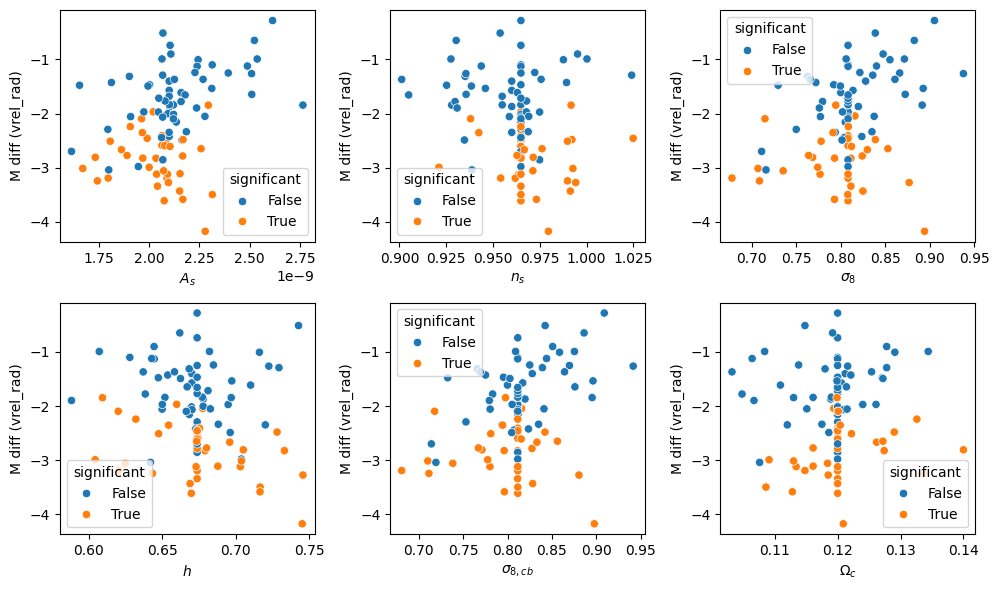

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = plt.subplots(2, 3, figsize=(10,6))

for i, feature in enumerate(top_features_vrel_rad_real):
    row = i // 3
    col = i % 3
    sns.scatterplot(x=cosmo_params_df[feature], y=mdiff_vrel_rad, hue=significance_vrel_rad, ax=ax[row, col])
    ax[row, col].set_xlabel(feature)
    ax[row, col].set_ylabel('M diff (vrel_rad)')
plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import spearmanr
for feature in top_features_vrel_rad_real:
    corr, pvalue = spearmanr(cosmo_params_df[feature], mdiff_vrel_rad)
    print(f'Spearman correlation between {feature} and M diff (vrel_rad): {corr:.3f}, p-value: {pvalue:.3e}')

Spearman correlation between $A_s$ and M diff (vrel_rad): 0.360, p-value: 3.999e-04
Spearman correlation between $n_s$ and M diff (vrel_rad): -0.231, p-value: 2.591e-02
Spearman correlation between $\sigma_8$ and M diff (vrel_rad): 0.314, p-value: 2.187e-03
Spearman correlation between $h$ and M diff (vrel_rad): -0.174, p-value: 9.476e-02
Spearman correlation between $\sigma_{8,cb}$ and M diff (vrel_rad): 0.295, p-value: 4.134e-03
Spearman correlation between $\Omega_c$ and M diff (vrel_rad): 0.090, p-value: 3.889e-01


In [25]:
from sklearn.ensemble import RandomForestClassifier

X = cosmo_params_df.drop(columns='Notes')
y = significance_vrel_rad.values

rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X, y)


,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


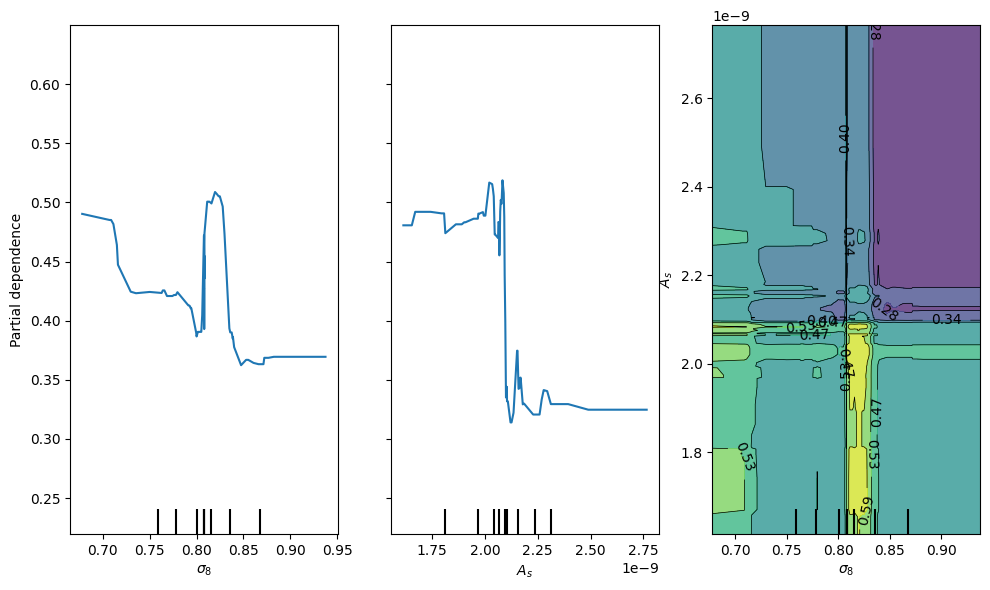

In [26]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Random forest classifier: rf
# Data matrix: X  (pandas DataFrame)
# Target y: boolean array (significant vs not)

fig, ax = plt.subplots(figsize=(10,6))

PartialDependenceDisplay.from_estimator(
    rf, 
    X, 
    features=[r'$\sigma_8$',r'$A_s$',(r'$\sigma_8$',r'$A_s$')], 
    kind='average', 
    ax=ax,
)

ax.set_xlabel(r'$\sigma_8$')
ax.set_ylabel(r'$P(\mathrm{significant})$')

plt.tight_layout()
plt.show()


In [27]:
X.columns

Index(['$\Omega_b$', '$\Omega_c$', '$h$', '$A_s$', '$n_s$', '$\alpha_s$',
       '$N_{ur}$', '$N_{ncdm}$', '$\Omega_{ncdm}$', '$w_0$', '$w_a$',
       '$\sigma_8$', '$\sigma_{8,cb}$'],
      dtype='object')

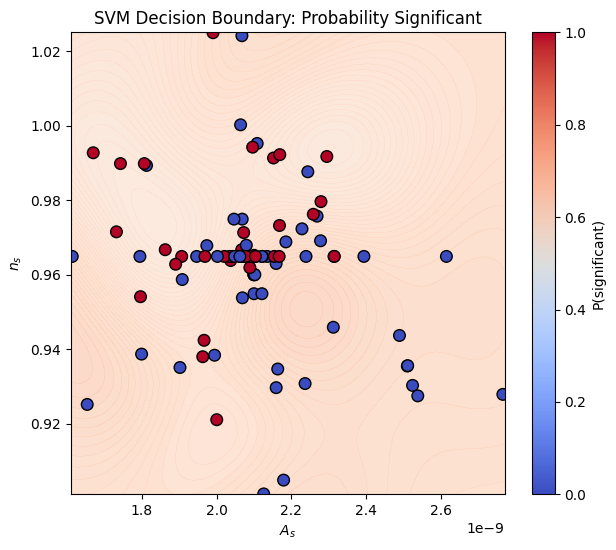

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# X: table of cosmological parameters (pandas DataFrame or numpy)
# y: boolean array (True = significant)

X = cosmo_params_df
y = significance_vrel_rad.values

feat1 = top_features_vrel_rad_real[0]
feat2 = top_features_vrel_rad_real[1]
X2 = X[[feat1, feat2]].values

# Build SVM pipeline: scale → SVM (RBF kernel)
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel='rbf', probability=True, C=3.0, gamma='scale'))
])

svm.fit(X2, y)

step1 = X2[0,0] - X2[1,0]
step2 = X2[0,1] - X2[1,1]

# Create a mesh grid for plotting
x_min, x_max = X2[:,0].min() - step1*0.1, X2[:,0].max() + step1*0.1
y_min, y_max = X2[:,1].min() - step2*0.1, X2[:,1].max() + step2*0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = svm.predict_proba(grid)[:,1].reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, probs, 50, cmap='RdBu', vmin=0, vmax=1, alpha=0.75)

# Decision contour
plt.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=2)

# Plot the cosmologies
plt.scatter(X2[:,0], X2[:,1], c=y, cmap='coolwarm', edgecolor='k', s=70)
plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title("SVM Decision Boundary: Probability Significant")
plt.colorbar(label='P(significant)')
plt.show()


## Combination of significant observables

### Practical filter

In [29]:
variables = ['mass_LG','vrel_tan','vrel_rad']
filt = 'Pract'

significance = [df_results.xs((variable,filt), level=('variable','filter'))['significant'].values for variable in variables]

y_mass_LG = (significance[0]).astype(int)
y_vtan = (significance[1]).astype(int)
y_vrad = (significance[2]).astype(int)

In [30]:
Y = pd.DataFrame({
    'vrel_rad': y_vrad,
    'vrel_tan': y_vtan,
    'mass_LG': y_mass_LG
}, index=cosmo_params_df.index)

In [31]:
# Bitmask-style meta-class encoding
Y['meta_class'] = (Y['vrel_rad'] * 1) + (Y['vrel_tan'] * 2) + (Y['mass_LG'] * 4)

# Label map for readability
labels = {
    0: 'None',
    1: 'v_rad only',
    2: 'v_tan only',
    3: 'v_rad + v_tan',
    4: 'mass only',
    5: 'v_rad + mass',
    6: 'v_tan + mass',
    7: 'all three'
}


In [32]:
Y['meta_class_name'] = Y['meta_class'].map(labels)
print(Y['meta_class_name'].value_counts())

meta_class_name
None             47
v_rad only       34
v_tan only        9
v_rad + v_tan     3
Name: count, dtype: int64


In [33]:
import numpy as np
def regroup(meta_class):
    if meta_class == 0:
        return 0  # No significant difference
    elif meta_class in [1, 2, 3]:
        return 1  # Kinematic only
    elif meta_class in [5, 7]:
        return 2  # Mass-related
    else:
        return np.nan

Y['meta_group'] = Y['meta_class'].map(regroup)

In [34]:
labels_group = {
    0: 'None',
    1: 'Kinematic only',
    2: 'Mass-related'
}

Y['meta_group_name'] = Y['meta_group'].map(labels_group)

In [35]:
print(Y['meta_group_name'].value_counts())

meta_group_name
None              47
Kinematic only    46
Name: count, dtype: int64


### Realisitc filter

In [36]:
variables = ['mass_LG','vrel_tan','vrel_rad']
filt = 'Real'

significance = [df_results.xs((variable,filt), level=('variable','filter'))['significant'].values for variable in variables]

y_mass_LG = (significance[0]).astype(int)
y_vtan = (significance[1]).astype(int)
y_vrad = (significance[2]).astype(int)

In [37]:
Y = pd.DataFrame({
    'vrel_rad': y_vrad,
    'vrel_tan': y_vtan,
    'mass_LG': y_mass_LG
}, index=cosmo_params_df.index)

In [38]:
# Bitmask-style meta-class encoding
Y['meta_class'] = (Y['vrel_rad'] * 1) + (Y['vrel_tan'] * 2) + (Y['mass_LG'] * 4)

# Label map for readability
labels = {
    0: 'None',
    1: 'v_rad only',
    2: 'v_tan only',
    3: 'v_rad + v_tan',
    4: 'mass only',
    5: 'v_rad + mass',
    6: 'v_tan + mass',
    7: 'all three'
}


In [39]:
Y['meta_class_name'] = Y['meta_class'].map(labels)
print(Y['meta_class_name'].value_counts())

meta_class_name
v_rad only       65
v_rad + v_tan    12
v_rad + mass      7
None              6
all three         2
v_tan only        1
Name: count, dtype: int64


In [40]:
Y[Y['meta_class_name']=='all three']

,vrel_rad,vrel_tan,mass_LG,meta_class,meta_class_name
cosmo,,,,,
c101,1,1,1,7,all three
c135,1,1,1,7,all three


In [41]:
import numpy as np
def regroup(meta_class):
    if meta_class == 0:
        return 0  # No significant difference
    elif meta_class in [1, 2, 3]:
        return 1  # Kinematic only
    elif meta_class in [5, 7]:
        return 2  # Mass-related
    else:
        return np.nan

Y['meta_group'] = Y['meta_class'].map(regroup)

In [42]:
labels_group = {
    0: 'None',
    1: 'Kinematic only',
    2: 'Mass-related'
}

Y['meta_group_name'] = Y['meta_group'].map(labels_group)

In [43]:
print(Y['meta_group_name'].value_counts())

meta_group_name
Kinematic only    78
Mass-related       9
None               6
Name: count, dtype: int64


## Random forest results

### Vrad

In [44]:
full_report_vrel_rad = [pd.read_csv('../results/' + suffix + '/random_forest_' + filt + '/full_report_vrel_rad.csv') for filt in ['Pract','Real']]
full_report_vrel_rad[0]

,0,1,accuracy,macro avg,weighted avg
0,"{'precision': 0.7333333333333333, 'recall': 1....","{'precision': 1.0, 'recall': 0.5, 'f1-score': ...",0.789474,"{'precision': 0.8666666666666667, 'recall': 0....","{'precision': 0.8456140350877193, 'recall': 0...."
1,"{'precision': 0.46153846153846156, 'recall': 0...","{'precision': 0.16666666666666666, 'recall': 0...",0.368421,"{'precision': 0.3141025641025641, 'recall': 0....","{'precision': 0.33738191632928477, 'recall': 0..."
2,"{'precision': 0.75, 'recall': 0.75, 'f1-score'...","{'precision': 0.5714285714285714, 'recall': 0....",0.684211,"{'precision': 0.6607142857142857, 'recall': 0....","{'precision': 0.6842105263157895, 'recall': 0...."
3,"{'precision': 0.5384615384615384, 'recall': 0....","{'precision': 0.2, 'recall': 0.142857142857142...",0.444444,"{'precision': 0.36923076923076925, 'recall': 0...","{'precision': 0.40683760683760684, 'recall': 0..."
4,"{'precision': 0.7272727272727273, 'recall': 0....","{'precision': 0.5714285714285714, 'recall': 0....",0.666667,"{'precision': 0.6493506493506493, 'recall': 0....","{'precision': 0.6666666666666666, 'recall': 0...."


In [45]:
full_report_vrel_rad[1]

,0,1,accuracy,macro avg,weighted avg
0,"{'precision': 0.0, 'recall': 0.0, 'f1-score': ...","{'precision': 0.9473684210526315, 'recall': 1....",0.947368,"{'precision': 0.47368421052631576, 'recall': 0...","{'precision': 0.8975069252077561, 'recall': 0...."
1,"{'precision': 0.0, 'recall': 0.0, 'f1-score': ...","{'precision': 0.8947368421052632, 'recall': 1....",0.894737,"{'precision': 0.4473684210526316, 'recall': 0....","{'precision': 0.8005540166204986, 'recall': 0...."
2,"{'precision': 0.0, 'recall': 0.0, 'f1-score': ...","{'precision': 0.8947368421052632, 'recall': 1....",0.894737,"{'precision': 0.4473684210526316, 'recall': 0....","{'precision': 0.8005540166204986, 'recall': 0...."
3,"{'precision': 0.0, 'recall': 0.0, 'f1-score': ...","{'precision': 0.9444444444444444, 'recall': 1....",0.944444,"{'precision': 0.4722222222222222, 'recall': 0....","{'precision': 0.8919753086419752, 'recall': 0...."
4,"{'precision': 0.0, 'recall': 0.0, 'f1-score': ...","{'precision': 0.9444444444444444, 'recall': 1....",0.944444,"{'precision': 0.4722222222222222, 'recall': 0....","{'precision': 0.8919753086419752, 'recall': 0...."


In [46]:
full_report_vrel_rad[0]['accuracy'].mean(), full_report_vrel_rad[1]['accuracy'].mean()

(np.float64(0.5906432748538012), np.float64(0.9251461988304094))

In [47]:
f1_scores_vrad = [pd.read_csv('../results/' + suffix + '/random_forest_' + filt + '/f1_scores_vrel_rad.csv') for filt in ['Pract','Real']]
f1_scores_vrad[0], f1_scores_vrad[1]

(   F1 Macro  F1 Weighted
 0  0.552581     0.578476,
    F1 Macro  F1 Weighted
 0  0.480472     0.889349)

### Vtan

In [48]:
full_report_vrel_tan = [pd.read_csv('../results/' + suffix + '/random_forest_' + filt + '/full_report_vrel_tan.csv') for filt in ['Pract','Real']]
full_report_vrel_tan[0]

,0,1,accuracy,macro avg,weighted avg
0,"{'precision': 1.0, 'recall': 0.941176470588235...","{'precision': 0.6666666666666666, 'recall': 1....",0.947368,"{'precision': 0.8333333333333333, 'recall': 0....","{'precision': 0.9649122807017543, 'recall': 0...."
1,"{'precision': 0.9230769230769231, 'recall': 0....","{'precision': 0.3333333333333333, 'recall': 0....",0.736842,"{'precision': 0.6282051282051282, 'recall': 0....","{'precision': 0.8299595141700405, 'recall': 0...."
2,"{'precision': 0.8888888888888888, 'recall': 1....","{'precision': 1.0, 'recall': 0.333333333333333...",0.894737,"{'precision': 0.9444444444444444, 'recall': 0....","{'precision': 0.9064327485380117, 'recall': 0...."
3,"{'precision': 0.9411764705882353, 'recall': 1....","{'precision': 1.0, 'recall': 0.5, 'f1-score': ...",0.944444,"{'precision': 0.9705882352941176, 'recall': 0....","{'precision': 0.9477124183006536, 'recall': 0...."
4,"{'precision': 0.8823529411764706, 'recall': 0....","{'precision': 0.0, 'recall': 0.0, 'f1-score': ...",0.833333,"{'precision': 0.4411764705882353, 'recall': 0....","{'precision': 0.7843137254901961, 'recall': 0...."


In [49]:
full_report_vrel_tan[1]

,0,1,accuracy,macro avg,weighted avg
0,"{'precision': 0.8888888888888888, 'recall': 1....","{'precision': 1.0, 'recall': 0.333333333333333...",0.894737,"{'precision': 0.9444444444444444, 'recall': 0....","{'precision': 0.9064327485380117, 'recall': 0...."
1,"{'precision': 0.8333333333333334, 'recall': 0....","{'precision': 0.0, 'recall': 0.0, 'f1-score': ...",0.789474,"{'precision': 0.4166666666666667, 'recall': 0....","{'precision': 0.7017543859649124, 'recall': 0...."
2,"{'precision': 0.8125, 'recall': 0.8125, 'f1-sc...","{'precision': 0.0, 'recall': 0.0, 'f1-score': ...",0.684211,"{'precision': 0.40625, 'recall': 0.40625, 'f1-...","{'precision': 0.6842105263157895, 'recall': 0...."
3,"{'precision': 0.8666666666666667, 'recall': 0....","{'precision': 0.3333333333333333, 'recall': 0....",0.777778,"{'precision': 0.6, 'recall': 0.6, 'f1-score': ...","{'precision': 0.7777777777777778, 'recall': 0...."
4,"{'precision': 0.8333333333333334, 'recall': 1....","{'precision': 0.0, 'recall': 0.0, 'f1-score': ...",0.833333,"{'precision': 0.4166666666666667, 'recall': 0....","{'precision': 0.6944444444444444, 'recall': 0...."


In [50]:
full_report_vrel_tan[0]['accuracy'].mean(), full_report_vrel_tan[1]['accuracy'].mean()

(np.float64(0.871345029239766), np.float64(0.795906432748538))

In [51]:
f1_scores_vrel_tan = [pd.read_csv('../results/' + suffix + '/random_forest_' + filt + '/f1_scores_vrel_tan.csv') for filt in ['Pract','Real']]
f1_scores_vrel_tan[0], f1_scores_vrel_tan[1]

(   F1 Macro  F1 Weighted
 0  0.702836      0.86691,
    F1 Macro  F1 Weighted
 0  0.524512     0.766823)